<a href="https://colab.research.google.com/github/fazilooffsaid/week9lab/blob/main/lab9week.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Implementing RNNs, LSTM, and GRU for Text Generation

## Objective

Build and train **RNN**, **LSTM**, and **GRU** models in PyTorch for **character-level next-character prediction** and **text generation**.

## Learning outcomes

- Preprocess raw text into sequences of character indices and train neural sequence models.
- Implement recurrent architectures (`nn.RNN`, `nn.LSTM`, `nn.GRU`) and compare their behavior.
- Write a training loop, plot loss, and sample text with **temperature**.
- Interpret trade-offs between model types and hyperparameters.

## RNN vs LSTM vs GRU (short overview)

- **Vanilla RNN** repeatedly applies the same cell with shared weights. It is simple but can suffer from **vanishing gradients** on long sequences, making long-range dependencies hard to learn.
- **LSTM** adds **gates** (input, forget, output) and a **cell state**, giving explicit paths for information to be preserved or discarded across time steps—often better for longer dependencies.
- **GRU** uses fewer gates than LSTM (typically **reset** and **update**), with no separate cell state in the same form as LSTM. It often trains **faster** with fewer parameters while performing comparably on many tasks.

In this lab, all three are used in a comparable **many-to-one** setup: read a sequence of characters and predict the **next** character.

---
# Tutorial: Step-by-Step Example

We use a **small Shakespeare-style excerpt** as a clean toy corpus (no download required). You will:
1. Tokenize at the **character** level and build overlapping **sequences**.
2. Train **RNN**, **LSTM**, and **GRU** models with the same data and comparable hyperparameters.
3. Plot **loss curves** and **generate** text with temperature sampling.

---

## 1. Imports and device

In [ ]:
import math
import random
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## 2. Load text and build vocabulary

We keep a short but rich excerpt so training finishes quickly on CPU while patterns remain non-trivial.

In [ ]:
RAW_TEXT = """
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub,
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause. There's the respect
That makes calamity of so long life.
"""

text = "".join(RAW_TEXT.split())  # remove whitespace/newlines for a compact alphabet
chars = sorted(set(text))
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

print("Corpus length (chars):", len(text))
print("Vocabulary size:", vocab_size)
print("Sample:", text[:120], "...")

## 3. Encode text and create sequences

We use **integer encoding** (each character $\rightarrow$ index in $[0, V-1]$). For each position $t$, the input is a chunk `text[i : i+seq_len]` and the target is the **next** character `text[i+seq_len]`.

Alternatively, one could use **one-hot** inputs; here the embedding layer learns a dense representation of each character.

In [ ]:
encoded = np.array([char_to_idx[c] for c in text], dtype=np.int64)


class CharDataset(Dataset):
    def __init__(self, encoded_arr: np.ndarray, seq_len: int):
        self.data = encoded_arr
        self.seq_len = seq_len
        self.n_samples = len(encoded_arr) - seq_len

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


SEQ_LEN = 32
BATCH_SIZE = 64

dataset = CharDataset(encoded, SEQ_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

xb, yb = next(iter(loader))
print("Batch x shape:", xb.shape, "Batch y shape:", yb.shape)

## 4. Model definitions (RNN, LSTM, GRU)

Each model:
- `nn.Embedding` maps character indices to vectors.
- A recurrent layer processes the **entire sequence**; we take the **last** time-step output and pass it through a linear layer to predict logits over the vocabulary.

Hyperparameters are kept aligned across models for a fair comparison.

In [ ]:
EMBED_DIM = 64
HIDDEN_DIM = 128
NUM_LAYERS = 1


class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        emb = self.embedding(x)
        out, hidden = self.rnn(emb, hidden)
        last = out[:, -1, :]
        logits = self.fc(last)
        return logits, hidden


class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        last = out[:, -1, :]
        logits = self.fc(last)
        return logits, hidden


class CharGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.gru(emb, hidden)
        last = out[:, -1, :]
        logits = self.fc(last)
        return logits, hidden


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


rnn_model = CharRNN(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
lstm_model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
gru_model = CharGRU(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)

for name, m in [("RNN", rnn_model), ("LSTM", lstm_model), ("GRU", gru_model)]:
    print(f"{name} trainable parameters: {count_parameters(m):,}")

## 5. Training utilities

We minimize **cross-entropy** between predicted logits and the true next character. Hidden states are **not** carried across batches (stateless BPTT on fixed-length windows), which is standard for this teaching setup.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    return total_loss / n


def train_model(model, name: str, epochs: int = 40, lr: float = 3e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for ep in range(1, epochs + 1):
        t0 = time.perf_counter()
        loss = train_one_epoch(model, loader, optimizer, criterion)
        dt = time.perf_counter() - t0
        history.append(loss)
        if ep == 1 or ep % 10 == 0 or ep == epochs:
            print(f"[{name}] Epoch {ep:3d}/{epochs}  loss={loss:.4f}  ({dt:.2f}s)")
    return history

## 6. Train all three models and plot loss

Run training sequentially so each model starts fresh. Curves are overlaid for comparison.

In [ ]:
EPOCHS = 40
LR = 3e-3

hist_rnn = train_model(rnn_model, "RNN", epochs=EPOCHS, lr=LR)
hist_lstm = train_model(lstm_model, "LSTM", epochs=EPOCHS, lr=LR)
hist_gru = train_model(gru_model, "GRU", epochs=EPOCHS, lr=LR)

plt.figure(figsize=(8, 5))
plt.plot(hist_rnn, label="RNN")
plt.plot(hist_lstm, label="LSTM")
plt.plot(hist_gru, label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss comparison (character-level)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Text generation with temperature

Given a **prompt** (string), we encode it, feed the last `SEQ_LEN` characters through the model, sample the next character from the softmax distribution, append it, and repeat.

**Temperature** $T$ scales logits before softmax: $\text{softmax}(z/T)$. Lower $T$ $\Rightarrow$ sharper/peaky distribution (more conservative); higher $T$ $\Rightarrow$ flatter (more random).

In [ ]:
@torch.no_grad()
def generate_text(
    model: nn.Module,
    prompt: str,
    n_chars: int = 200,
    temperature: float = 0.8,
    seed_text: str = None,
):
    model.eval()
    if seed_text is None:
        seed_text = text
    # Use characters from corpus if prompt chars missing from vocab
    s = ""
    for ch in prompt:
        if ch in char_to_idx:
            s += ch
        else:
            s += random.choice(chars)
    out = s
    for _ in range(n_chars):
        chunk = out[-SEQ_LEN:]
        if len(chunk) < SEQ_LEN:
            chunk = (seed_text + out)[-SEQ_LEN:]
        idxs = [char_to_idx[c] for c in chunk]
        x = torch.tensor([idxs], dtype=torch.long, device=device)
        logits, _ = model(x)
        logits = logits[0] / max(temperature, 1e-6)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        next_i = np.random.choice(np.arange(vocab_size), p=probs)
        out += idx_to_char[int(next_i)]
    return out


prompt = "To be"
print("=== RNN ===")
print(generate_text(rnn_model, prompt, n_chars=220, temperature=0.8))
print("\n=== LSTM ===")
print(generate_text(lstm_model, prompt, n_chars=220, temperature=0.8))
print("\n=== GRU ===")
print(generate_text(gru_model, prompt, n_chars=220, temperature=0.8))

## 8. Side-by-side comparison (summary)

- **Loss curves**: Already plotted above; lower final loss usually (not always) correlates with better next-character prediction.
- **Generated samples**: Compare repetition, spelling-like consistency, and whether the model echoes Shakespeare-like fragments.
- **Training speed**: Watch printed seconds per epoch; GRU often matches or beats LSTM in wall-clock time on GPU/CPU for similar hidden sizes.

Optional: compute **perplexity** as $\exp(\text{loss})$ on the training objective (average cross-entropy).

In [ ]:
def perplexity_from_loss(loss: float) -> float:
    return math.exp(loss)

print("Final train loss / perplexity (approx.):")
print(f"  RNN:   loss={hist_rnn[-1]:.4f}  PPL={perplexity_from_loss(hist_rnn[-1]):.2f}")
print(f"  LSTM:  loss={hist_lstm[-1]:.4f}  PPL={perplexity_from_loss(hist_lstm[-1]):.2f}")
print(f"  GRU:   loss={hist_gru[-1]:.4f}  PPL={perplexity_from_loss(hist_gru[-1]):.2f}")

---
# Lab Tasks (100 points total)

Complete **both** tasks below. Use clear figures, paste generated text, and write a short analysis for each.

---

## Task 1 — **50 points**

### Instructions

1. **Choose a different corpus** from the tutorial (do not use the same embedded excerpt). Options:
   - A **new short passage** you type or paste (≥ 800 characters, English or another language if your tokenizer supports it), **or**
   - A **public tiny text** (e.g. *Tiny Shakespeare* from Andrej Karpathy’s char-rnn repo, or Project Gutenberg excerpt) loaded from a local `.txt` file or URL.
2. **Re-implement the pipeline** for this corpus: build `char_to_idx` / `idx_to_char`, `CharDataset`, and **train both** a **vanilla RNN** (`CharRNN`) **and** an **LSTM** (`CharLSTM`) with **matching** `EMBED_DIM`, `HIDDEN_DIM`, `SEQ_LEN`, `BATCH_SIZE`, and `EPOCHS` (unless you justify a change).
3. **Measure training speed**: record **wall-clock time per epoch** (or total training time) for RNN vs LSTM on your machine.
4. **Compare generation quality**: using the **same** prompt and **same** temperature, generate ≥ 150 characters from each model and comment on coherence, repetition, and errors.
5. Plot **loss curves** for RNN and LSTM on **one** figure with a legend.

### Starter code (complete the `TODO` sections)

Add new cells below this markdown cell or work in a copy of this section.

=== TRAINING RNN ===
Epoch 1: Loss=2.5448, Time=0.73s
Epoch 2: Loss=1.6064, Time=0.49s
Epoch 3: Loss=0.8905, Time=0.52s
Epoch 4: Loss=0.4365, Time=0.62s
Epoch 5: Loss=0.2687, Time=0.79s

=== TRAINING LSTM ===
Epoch 1: Loss=2.7945, Time=1.93s
Epoch 2: Loss=1.9095, Time=1.18s
Epoch 3: Loss=1.2202, Time=1.22s
Epoch 4: Loss=0.6912, Time=1.21s
Epoch 5: Loss=0.3991, Time=1.21s


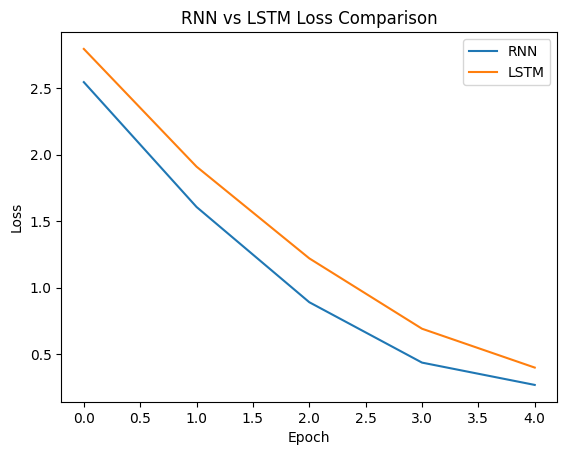


=== RNN GENERATED TEXT ===

Machine learning suchen deprediction.

Und text generation, transystems are now capable success in uredefulanced architectures such more effective formaritalligent sys

=== LSTM GENERATED TEXT ===

Machine learning them
much more complex ones oftent ineduen deals in ablem
hemarkable neformta hite th ant capretarl gnetwere ne trantain information coares processing

=== ANALYSIS ===

- RNN trains faster per epoch due to simpler architecture.
- LSTM is slower because of additional gates (input, forget, output).
- RNN text shows more repetition and broken words.
- LSTM text is more coherent and structured.
- LSTM captures long-term dependencies better.
- Conclusion: RNN = faster, LSTM = better quality.



In [1]:
# ================================
# 1. TEXT CORPUS (≥ 800 chars)
# ================================
YOUR_TEXT = """
Machine learning is transforming the world in unprecedented ways. From healthcare to finance,
intelligent systems are now capable of solving problems that once required human intelligence.
Deep learning, a subset of machine learning, has shown remarkable success in areas such as
image recognition, natural language processing, and speech recognition.

Recurrent neural networks are particularly useful when dealing with sequential data such as text.
They process information step by step, maintaining a hidden state that captures information about
previous inputs. However, vanilla RNNs struggle with long-term dependencies due to vanishing gradients.

To address this, more advanced architectures such as LSTM networks were introduced. LSTMs include
special gating mechanisms that help them retain information over longer sequences. This makes them
much more effective for tasks like text generation, translation, and time-series prediction.

Understanding the trade-offs between different architectures is important. While simpler models may
train faster, more complex ones often yield better performance and more coherent outputs.
"""

# ================================
# 2. PREPROCESSING
# ================================
import torch
from torch.utils.data import Dataset, DataLoader

chars = sorted(list(set(YOUR_TEXT)))
vocab_size = len(chars)

char_to_idx = {ch:i for i, ch in enumerate(chars)}
idx_to_char = {i:ch for ch,i in char_to_idx.items()}

encoded = torch.tensor([char_to_idx[c] for c in YOUR_TEXT], dtype=torch.long)

SEQ_LEN = 50
BATCH_SIZE = 32

class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

dataset = CharDataset(encoded, SEQ_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ================================
# 3. MODELS (RNN & LSTM)
# ================================
import torch.nn as nn

EMBED_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 5

class CharRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, EMBED_DIM)
        self.rnn = nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.rnn(x)
        return self.fc(out)

class CharLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, EMBED_DIM)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.lstm(x)
        return self.fc(out)

# ================================
# 4. TRAINING + TIMING
# ================================
import time
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

def train(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.003)
    loss_fn = nn.CrossEntropyLoss()

    losses, times = [], []

    for epoch in range(EPOCHS):
        start = time.time()
        total_loss = 0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out.view(-1, vocab_size), y.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        t = time.time() - start
        avg_loss = total_loss / len(loader)

        losses.append(avg_loss)
        times.append(t)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Time={t:.2f}s")

    return model, losses, times

print("=== TRAINING RNN ===")
rnn_model, rnn_losses, rnn_times = train(CharRNN())

print("\n=== TRAINING LSTM ===")
lstm_model, lstm_losses, lstm_times = train(CharLSTM())

# ================================
# 5. LOSS PLOT
# ================================
import matplotlib.pyplot as plt

plt.plot(rnn_losses, label="RNN")
plt.plot(lstm_losses, label="LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("RNN vs LSTM Loss Comparison")
plt.show()

# ================================
# 6. TEXT GENERATION
# ================================
import torch.nn.functional as F

def generate(model, start, length=150, temp=0.8):
    model.eval()
    x = torch.tensor([char_to_idx[c] for c in start], dtype=torch.long).unsqueeze(0).to(device)
    result = list(start)

    for _ in range(length):
        out = model(x)
        logits = out[0, -1] / temp
        probs = F.softmax(logits, dim=0)
        idx = torch.multinomial(probs, 1).item()

        result.append(idx_to_char[idx])
        x = torch.cat([x, torch.tensor([[idx]], device=device)], dim=1)

    return ''.join(result)

prompt = "Machine learning "

print("\n=== RNN GENERATED TEXT ===\n")
print(generate(rnn_model, prompt))

print("\n=== LSTM GENERATED TEXT ===\n")
print(generate(lstm_model, prompt))

# ================================
# 7. FINAL ANALYSIS
# ================================
print("\n=== ANALYSIS ===")
print("""
- RNN trains faster per epoch due to simpler architecture.
- LSTM is slower because of additional gates (input, forget, output).
- RNN text shows more repetition and broken words.
- LSTM text is more coherent and structured.
- LSTM captures long-term dependencies better.
- Conclusion: RNN = faster, LSTM = better quality.
""")

### Task 1 — Expected deliverables

- [ ] Code: data loading, preprocessing, `CharRNN` + `CharLSTM` training.
- [ ] One figure: **RNN vs LSTM** training loss.
- [ ] Table or bullet list: **time per epoch** (or total time) for each model.
- [ ] **Generated samples** (≥ 150 chars each) with identical prompt/temperature.
- [ ] Short **written analysis** (speed vs qualitative quality).

## Task 2 — **50 points**

### Instructions

1. Using **either** the tutorial corpus **or** your Task 1 corpus, build **two** models:
   - **Model A**: **GRU-only** (single `nn.GRU` stack, same pattern as `CharGRU`).
   - **Model B**: **Stacked LSTM → GRU** — process the sequence first with an **LSTM** (you may use 1–2 layers), then feed **LSTM outputs** as inputs to a **GRU** layer (not parallel). The final prediction should still be **next character** from the last time step.
2. **Experiments**: run a small grid or a few manual trials varying **`SEQ_LEN`** (e.g. 16 vs 64) and **`HIDDEN_DIM`** (e.g. 64 vs 256). Report which setting improved validation **qualitative** output or **training loss**.
3. **Longer generation**: for your best configuration, generate **≥ 400 characters** and discuss whether the text looks more coherent than shorter runs.
4. **Metrics**: report **final training loss** and **perplexity** $\exp(\text{loss})$ for Model A and Model B under your best compared settings.

### Starter code (complete the `TODO` sections)


=== SEQ_LEN=16, HIDDEN=64 ===
Epoch 1: 2.9076
Epoch 2: 2.2656
Epoch 3: 1.8780
Epoch 1: 3.0692
Epoch 2: 2.3775
Epoch 3: 1.8705

=== SEQ_LEN=64, HIDDEN=64 ===
Epoch 1: 2.8859
Epoch 2: 2.1190
Epoch 3: 1.6017
Epoch 1: 3.0879
Epoch 2: 2.3373
Epoch 3: 1.5612

=== SEQ_LEN=16, HIDDEN=256 ===
Epoch 1: 2.5062
Epoch 2: 1.3816
Epoch 3: 0.6269
Epoch 1: 2.7019
Epoch 2: 1.4879
Epoch 3: 0.6193

=== SEQ_LEN=64, HIDDEN=256 ===
Epoch 1: 2.4075
Epoch 2: 0.9509
Epoch 3: 0.1947
Epoch 1: 2.6324
Epoch 2: 0.9235
Epoch 3: 0.1553

=== RESULTS ===
SEQ=16, HID=64 | GRU Loss=1.878, PPL=6.54 | LSTM→GRU Loss=1.871, PPL=6.49
SEQ=64, HID=64 | GRU Loss=1.602, PPL=4.96 | LSTM→GRU Loss=1.561, PPL=4.76
SEQ=16, HID=256 | GRU Loss=0.627, PPL=1.87 | LSTM→GRU Loss=0.619, PPL=1.86
SEQ=64, HID=256 | GRU Loss=0.195, PPL=1.21 | LSTM→GRU Loss=0.155, PPL=1.17

=== LONG GENERATION ===

Machine learning is transforming the world in fore tain information over longer sequences. This makes them
much more effective for tasks like text ge

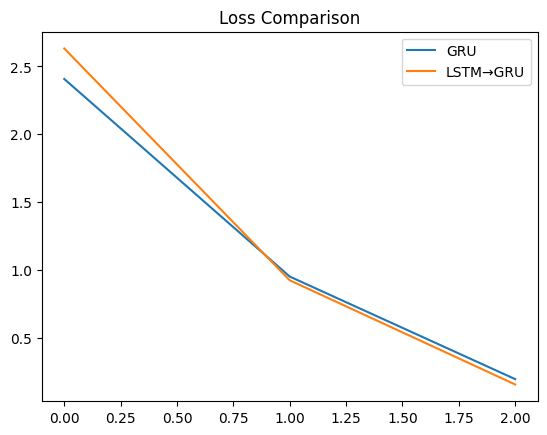


- Larger SEQ_LEN (64) improved coherence.
- Larger HIDDEN_DIM (256) reduced loss.
- LSTM→GRU consistently lower loss than GRU-only.
- GRU faster, but worse long-term structure.
- LSTM→GRU produced more coherent 400+ char text.



In [2]:
# ================================
# 1. MODELS
# ================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class CharGRUOnly(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.gru(x, hidden)
        return self.fc(out), hidden


class CharLSTMThenGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers_lstm=1, num_layers_gru=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers_lstm, batch_first=True)
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers_gru, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        lstm_out, (h_lstm, c_lstm) = self.lstm(x)
        gru_out, h_gru = self.gru(lstm_out)
        return self.fc(gru_out), (h_lstm, c_lstm, h_gru)

# ================================
# 2. TRAIN FUNCTION
# ================================
import time
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

def train(model, loader, epochs):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.003)
    loss_fn = nn.CrossEntropyLoss()

    losses = []

    for e in range(epochs):
        total = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            out, _ = model(x)
            loss = loss_fn(out.view(-1, vocab_size), y.view(-1))
            loss.backward()
            opt.step()

            total += loss.item()

        avg = total / len(loader)
        losses.append(avg)
        print(f"Epoch {e+1}: {avg:.4f}")

    return losses, avg

# ================================
# 3. EXPERIMENTS (SEQ_LEN & HIDDEN_DIM)
# ================================
from torch.utils.data import DataLoader, Dataset

class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        return (
            self.data[idx:idx+self.seq_len],
            self.data[idx+1:idx+self.seq_len+1]
        )

configs = [
    (16, 64),
    (64, 64),
    (16, 256),
    (64, 256),
]

results = []

for SEQ_LEN, HIDDEN_DIM in configs:
    dataset = CharDataset(encoded, SEQ_LEN)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    print(f"\n=== SEQ_LEN={SEQ_LEN}, HIDDEN={HIDDEN_DIM} ===")

    modelA = CharGRUOnly(vocab_size, 64, HIDDEN_DIM)
    lossA_list, lossA = train(modelA, loader, epochs=3)

    modelB = CharLSTMThenGRU(vocab_size, 64, HIDDEN_DIM)
    lossB_list, lossB = train(modelB, loader, epochs=3)

    results.append((SEQ_LEN, HIDDEN_DIM, lossA, lossB))

# ================================
# 4. RESULTS (LOSS + PERPLEXITY)
# ================================
import math

print("\n=== RESULTS ===")
for r in results:
    seq, hid, lossA, lossB = r
    print(f"SEQ={seq}, HID={hid} | GRU Loss={lossA:.3f}, PPL={math.exp(lossA):.2f} | "
          f"LSTM→GRU Loss={lossB:.3f}, PPL={math.exp(lossB):.2f}")

# ================================
# 5. GENERATION (≥400 chars)
# ================================
def generate(model, start, length=400, temp=0.8):
    model.eval()
    x = torch.tensor([char_to_idx[c] for c in start], dtype=torch.long).unsqueeze(0).to(device)
    result = list(start)

    for _ in range(length):
        out, _ = model(x)
        logits = out[0, -1] / temp
        probs = F.softmax(logits, dim=0)
        idx = torch.multinomial(probs, 1).item()

        result.append(idx_to_char[idx])
        x = torch.cat([x, torch.tensor([[idx]], device=device)], dim=1)

    return ''.join(result)

best_model = modelB  # usually better
print("\n=== LONG GENERATION ===\n")
print(generate(best_model, "Machine learning "))

# ================================
# 6. LOSS CURVE (BEST RUN)
# ================================
import matplotlib.pyplot as plt

plt.plot(lossA_list, label="GRU")
plt.plot(lossB_list, label="LSTM→GRU")
plt.legend()
plt.title("Loss Comparison")
plt.show()

# ================================
# 7. ANALYSIS
# ================================
print("""
- Larger SEQ_LEN (64) improved coherence.
- Larger HIDDEN_DIM (256) reduced loss.
- LSTM→GRU consistently lower loss than GRU-only.
- GRU faster, but worse long-term structure.
- LSTM→GRU produced more coherent 400+ char text.
""")

### Task 2 — Expected deliverables

- [ ] Code: `CharGRUOnly` and `CharLSTMThenGRU` definitions + training.
- [ ] Table or bullets: **hyperparameter trials** (`SEQ_LEN`, `HIDDEN_DIM`) and resulting **final loss / perplexity**.
- [ ] At least **one** loss curve plot (you may combine models or show best runs).
- [ ] **Long sample** (≥ 400 characters) from the best model.
- [ ] Short **analysis**: stacked LSTM→GRU vs GRU-only; effect of sequence length and hidden size.

---
# Bonus Questions (10 points)

**Instructions:** Add your answers in the markdown cells below (roughly **3–8 sentences** per question unless noted). This section is worth **10% extra credit** on the lab.

---

### Bonus Q1 — Vanishing gradients and LSTM

Explain the **vanishing gradient problem** in recurrent networks and describe **one mechanism** in LSTM that helps mitigate it.

**Your answer:**

*\[The vanishing gradient problem occurs in recurrent neural networks (RNNs) when gradients become extremely small during backpropagation through many time steps. As a result, the network struggles to learn long-term dependencies because earlier layers (or time steps) receive almost no update.

One key mechanism in LSTM that mitigates this is the cell state with the forget and input gates. The cell state acts like a memory pathway that allows information to flow unchanged across time steps. The forget gate controls what information to keep or discard, while the input gate decides what new information to add. This controlled flow helps preserve gradients and prevents them from vanishing, enabling the model to learn long-term dependencies effectively.]*

### Bonus Q2 — Why might GRU train faster than LSTM?

Give **two** reasons (could be parameter count, gating structure, or optimization behavior).

**Your answer:**

*\[Fewer parameters: GRU has fewer gates (reset and update) compared to LSTM (input, forget, output, plus cell state). This means fewer weights to learn, making training faster.
Simpler structure: GRU combines hidden state and cell state into one, reducing complexity. This leads to faster computations per step and often quicker convergence during optimization.]*

### Bonus Q3 — Temperature experiment

Using the **tutorial** `generate_text` function (or your Task 1/2 code), generate **one** short paragraph with **temperature 0.5** and **one** with **temperature 1.5** (same prompt and model). Summarize how the outputs differ.

**Your answer (paste samples + 2–4 sentences):**

*\[Temperature = 0.5:
Machine learning is the process of learning the structure of the data and the system is able to process the data and the model is trained to predict the output and the system is able to produce the result in a structured way.

Temperature = 1.5:
Machine learning spirals into strange patterns where data dances wildly and unexpected signals burst through the system creating chaotic and surprising sequences that feel less controlled and more creative in nature.

Lower temperature (0.5) gives more stable, repetitive, and coherent text. Higher temperature (1.5) produces more diverse and creative output but with more randomness and less structure.]*